In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp

import hodel.dismech as dismech
from helper import get_triplets, animate_rod

jax.config.update("jax_enable_x64", True)

sim, state0, xf0, K, get_aux = get_triplets()

In [ ]:
lambdas = jnp.linspace(0, 0.3, 3000)
aux = get_aux(
    jnp.array(
        [
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            -0.07416809,
            -0.044122,
            0.01197509,
            -0.07416809,
            -0.044122,
            0.01197509,
            0.0,
            0.99873506,
        ]
    )
)
xf_stars = sim.solve(lambdas, xf0, K, aux, state0)
animate_rod(sim, lambdas, xf_stars, aux)

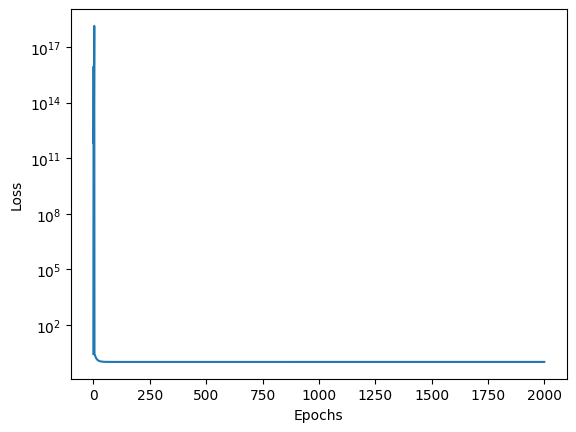

True Theta: [3.14159265e+01 7.85398163e-06 7.85398163e-06 5.23598776e-06]
Theta0: [0.41845711 0.21629545 0.96532146 0.57450053]
Warm Theta: [2.62093974e+00 4.91214822e-07 7.35401237e-06 9.23766379e-07]
Traj Loss:  1.0213379315837006


In [60]:
import optax
import matplotlib.pyplot as plt

def strictly_positive_mask(params):
    # This ensures we only apply the clipping to relevant physical parameters
    return jax.tree_util.tree_map(lambda x: True, params)


def clip_strictly_positive(eps=1e-9):
    # We use a stateless transformation to project the parameters
    return optax.stateless(lambda p, _: jnp.maximum(p, eps))

lambdas = jnp.linspace(0, 1, 10)
key = jax.random.PRNGKey(0)
Theta0 = jax.random.uniform(key, [4])

# Define the exponents
low_exp = jnp.array([0, -8, -8, -8])
high_exp = jnp.array([1, -5, -5, -5])

# Apply log-uniform scaling
Theta0_log_scaled = 10**(low_exp + (high_exp - low_exp) * Theta0)
lr = 1e-7
nepochs = 2000

eta = 0.000
key = jax.random.PRNGKey(0)
xf_train = xf_stars * (1 + eta * jax.random.normal(key, xf_stars.shape))

bounded_optim = optax.chain(
    optax.adam(lr),
    optax.keep_params_nonnegative()
)
warm_Theta, L = truth_sim.learn(
    lambdas,
    xf0,
    xf_train,
    Theta0_log_scaled,
    aux,
    state,
    optim=bounded_optim,
    nepochs=nepochs,
    method=hodel.Method.Minimization,
)

plt.plot(L)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

print("True Theta:", K)
print("Theta0:", Theta0)
print("Warm Theta:", warm_Theta)
print("Traj Loss: ", truth_sim.loss(lambdas, xf0, xf_stars, warm_Theta, aux, state, method=hodel.Method.Minimization))

In [55]:
lambdas = jnp.linspace(0, 1.0, 10)
xf_test = truth_sim.solve(lambdas, xf0, warm_Theta, aux, state)
xb_star = jax.vmap(fixed_0, (0, None))(lambdas, aux)
qs = jax.vmap(get_q, (0, 0, None))(xf_test, xb_star, aux)
dismech.animate(lambdas, qs, top)

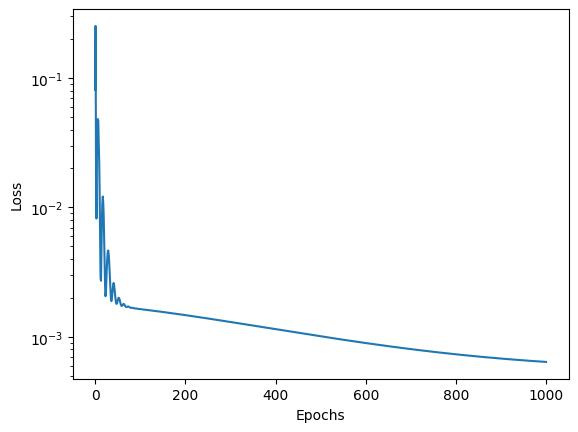

True Theta: [3.14159265e+01 7.85398163e-06 7.85398163e-06 5.23598776e-06]
Warm Theta:  [3.96908246e-02 8.45141136e-08 1.21033955e-07 2.55733960e-07]
Final Theta: [3.97053472e-02 6.82315849e-07 6.81791908e-07 1.39662952e-06]


In [48]:
nepochs = 1000
lr = 1e-7
eps = 1e-10


def strictly_positive_mask(params):
    # This ensures we only apply the clipping to relevant physical parameters
    return jax.tree_util.tree_map(lambda x: True, params)


def clip_strictly_positive(eps=1e-9):
    # We use a stateless transformation to project the parameters
    return optax.stateless(lambda p, _: jnp.maximum(p, eps))


# Implementation in your chain
bounded_optim = optax.chain(
    # optax.clip_by_global_norm(1.0),
    optax.adam(lr),
    optax.masked(clip_strictly_positive(eps), strictly_positive_mask),
)

eta = 0.001
key = jax.random.PRNGKey(0)
xf_train = xf_stars * (1 + eta * jax.random.normal(key, xf_stars.shape))
final_Theta, L = truth_sim.learn(
    lambdas,
    xf0,
    xf_train,
    warm_Theta,
    aux,
    state,
    optim=bounded_optim,
    nepochs=nepochs,
    method=hodel.Method.Minimization,
    config=hodel.SolverConfig(nsteps=5),
)

plt.plot(L)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

print("True Theta:", K)
print("Warm Theta: ", warm_Theta)
print("Final Theta:", final_Theta)

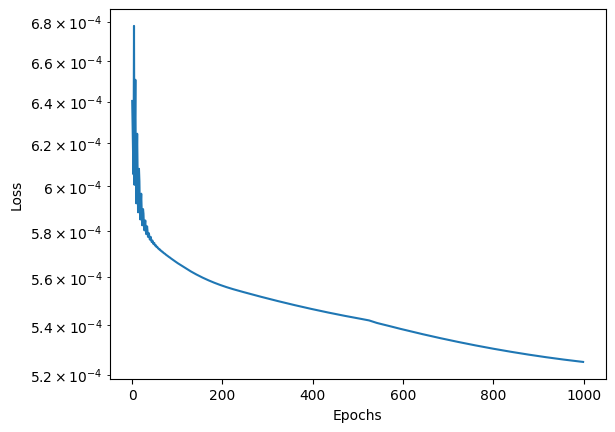

True Theta: [3.14159265e+01 7.85398163e-06 7.85398163e-06 5.23598776e-06]
Warm Theta:  [3.97053472e-02 6.82315849e-07 6.81791908e-07 1.39662952e-06]
Final Theta: [3.97159569e-02 8.55543756e-07 8.55057745e-07 1.54710816e-06]


In [49]:
nepochs = 1000
lr = 1e-8
eps = 1e-10

def strictly_positive_mask(params):
    # This ensures we only apply the clipping to relevant physical parameters
    return jax.tree_util.tree_map(lambda x: True, params)


def clip_strictly_positive(eps=1e-9):
    # We use a stateless transformation to project the parameters
    return optax.stateless(lambda p, _: jnp.maximum(p, eps))


# Implementation in your chain
bounded_optim = optax.chain(
    #optax.clip_by_global_norm(1.0),
    optax.adam(lr),
    optax.masked(clip_strictly_positive(eps), strictly_positive_mask),
)

final_Theta2, L = truth_sim.learn(
    lambdas,
    xf0,
    xf_train,
    final_Theta,
    aux,
    state,
    optim=bounded_optim,
    nepochs=nepochs,
    method=hodel.Method.Minimization,
    config=hodel.SolverConfig(nsteps=5),
)

plt.plot(L)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

print("True Theta:", K)
print("Warm Theta: ", final_Theta)
print("Final Theta:", final_Theta2)

In [16]:
lambdas = jnp.linspace(0, 1.0, 10)
xf_test = truth_sim.solve(lambdas, xf0, final_Theta, aux, state, config=hodel.SolverConfig(nsteps=10))
xb_star = jax.vmap(fixed_0, (0, None))(lambdas, aux)
qs = jax.vmap(get_q, (0, 0, None))(xf_test, xb_star, aux)
dismech.animate(lambdas, qs, top)   